In [45]:
import pandas as pd


df_tesla = pd.read_csv('./data/TESLA Search Trend vs Price.csv')
df_unemployment = pd.read_csv("./data/UE Benefits Search vs UE Rate 2004-19.csv")

df_btc_search = pd.read_csv('./data/Bitcoin Search Trend.csv')
df_btc_price = pd.read_csv('./data/Daily Bitcoin Price.csv')

In [46]:
print("Shapes of Tesla         = ", df_tesla.shape)
print("Shapes of UnEmployment  = ", df_unemployment.shape)
print("Shapes of BTC Price     = ", df_btc_price.shape)
print("Shapes of BTC Search    = ", df_btc_search.shape)

Shapes of Tesla         =  (124, 3)
Shapes of UnEmployment  =  (181, 3)
Shapes of BTC Price     =  (2204, 3)
Shapes of BTC Search    =  (73, 2)


In [47]:
print("Columns = ",df_tesla.columns)
print("Columns = ",df_unemployment.columns)
print("Columns = ",df_btc_price.columns)
print("Columns = ",df_btc_search.columns)

Columns =  Index(['MONTH', 'TSLA_WEB_SEARCH', 'TSLA_USD_CLOSE'], dtype='str')
Columns =  Index(['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE'], dtype='str')
Columns =  Index(['DATE', 'CLOSE', 'VOLUME'], dtype='str')
Columns =  Index(['MONTH', 'BTC_NEWS_SEARCH'], dtype='str')


In [48]:
print(f'Largest value for Tesla in Web Search: {df_tesla.TSLA_WEB_SEARCH.max()}')
print(f'Smallest value for Tesla in Web Search: {df_tesla.TSLA_WEB_SEARCH.min()}')

Largest value for Tesla in Web Search: 31
Smallest value for Tesla in Web Search: 2


In [49]:
df_tesla.describe()

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
count,124.000000,124.000000
mean,8.725806,50.962145
std,5.870332,65.908389
min,2.000000,3.896000
25%,3.750000,7.352500
50%,8.000000,44.653000
75%,12.000000,58.991999
max,31.000000,498.320007


In [50]:
df_btc_search.describe()

,BTC_NEWS_SEARCH
count,73.000000
mean,15.013699
std,15.146959
min,3.000000
25%,5.000000
50%,14.000000
75%,18.000000
max,100.000000


In [51]:
df_btc_price.describe()

,CLOSE,VOLUME
count,2203.000000,2.203000e+03
mean,4429.421245,8.043622e+09
std,4148.150071,1.176529e+10
min,178.102997,5.914570e+06
25%,433.629502,6.029915e+07
50%,3637.520020,2.018890e+09
75%,7997.372803,1.322478e+10
max,19497.400391,7.415677e+10


In [52]:
df_unemployment.describe()

,UE_BENEFITS_WEB_SEARCH,UNRATE
count,181.000000,181.000000
mean,35.110497,6.217680
std,20.484925,1.891859
min,14.000000,3.700000
25%,21.000000,4.700000
50%,26.000000,5.400000
75%,45.000000,7.800000
max,100.000000,10.000000


In [53]:
# print(df_tesla.isna().count())
# print(df_tesla.count())
# print("="*70)
# print(df_unemployment.isna().count())
# print(df_unemployment.count())
# print("="*70)
# print(df_btc_price.isna().count())
# print(df_btc_price.count())
# print("="*70)
# print(df_btc_search.isna().count())
# print(df_btc_search.count())
# print("="*70)

In [54]:
# df_btc_search.isna().values.any()
df_btc_price[df_btc_price.CLOSE.isna()]

,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


In [58]:
### NOW DROP NAN value from price df of btc

df_btc_price.dropna(inplace=True)

df_btc_price.isna().values.sum()
df_btc_price

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,2.105680e+07
1,2014-09-18,424.440002,3.448320e+07
2,2014-09-19,394.795990,3.791970e+07
3,2014-09-20,408.903992,3.686360e+07
4,2014-09-21,398.821014,2.658010e+07
...,...,...,...
2199,2020-09-24,10745.548828,2.301754e+10
2200,2020-09-25,10702.290039,2.123255e+10
2201,2020-09-26,10754.437500,1.810501e+10
2202,2020-09-27,10774.426758,1.801688e+10


In [ ]:
type(df_btc_price.DATE)
type(df_unemployment.MONTH)
type(df_btc_search.MONTH)
type(df_tesla.MONTH)

pandas.Series

In [64]:
df_tesla.MONTH = pd.to_datetime(df_tesla.MONTH)
df_btc_search.MONTH = pd.to_datetime(df_btc_search.MONTH)
df_unemployment.MONTH = pd.to_datetime(df_unemployment.MONTH)
df_btc_price.DATE = pd.to_datetime(df_btc_price.DATE)

In [76]:
df_tesla.MONTH.head()
df_btc_price.DATE.head()

0   2014-09-17
1   2014-09-18
2   2014-09-19
3   2014-09-20
4   2014-09-21
Name: DATE, dtype: datetime64[us]

In [91]:
df_btc_monthly = df_btc_price.resample('ME', on='DATE').last()
# print(df_btc_monthly.shape)
# print(df_btc_price.shape)
# print(df_btc_monthly.head())
print(df_btc_monthly)

                   CLOSE        VOLUME
DATE                                  
2014-09-30    386.944000  3.470730e+07
2014-10-31    338.321014  1.254540e+07
2014-11-30    378.046997  9.194440e+06
2014-12-31    320.192993  1.394290e+07
2015-01-31    217.464005  2.334820e+07
...                  ...           ...
2020-05-31   9461.058594  2.777329e+10
2020-06-30   9137.993164  1.573580e+10
2020-07-31  11323.466797  2.316047e+10
2020-08-31  11680.820313  2.228593e+10
2020-09-30  10912.536133  2.122653e+10

[73 rows x 2 columns]


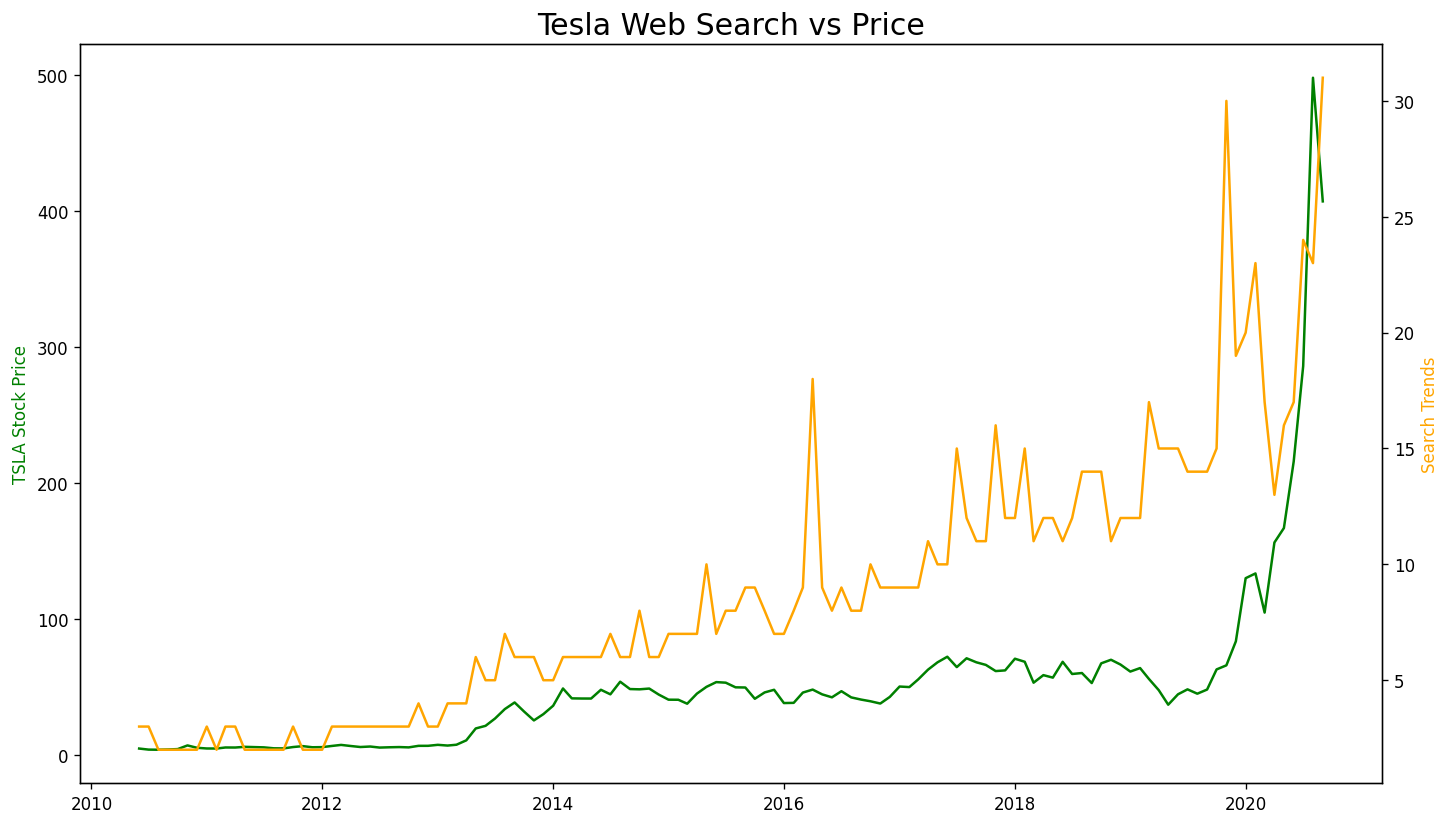

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi=120) 
plt.title('Tesla Web Search vs Price', fontsize=18)

ax1= plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel('TSLA Stock Price', color='green')
ax2.set_ylabel("Search Trends", color='orange')

ax1.plot(df_tesla.MONTH, df_tesla.TSLA_USD_CLOSE, color='green')
ax2.plot(df_tesla.MONTH,  df_tesla.TSLA_WEB_SEARCH, color='orange')

In [99]:
import matplotlib.dates as mdates


years = mdates.YearLocator()
months = mdates.MonthLocator()
year_fmt = mdates.DateFormatter("%Y")

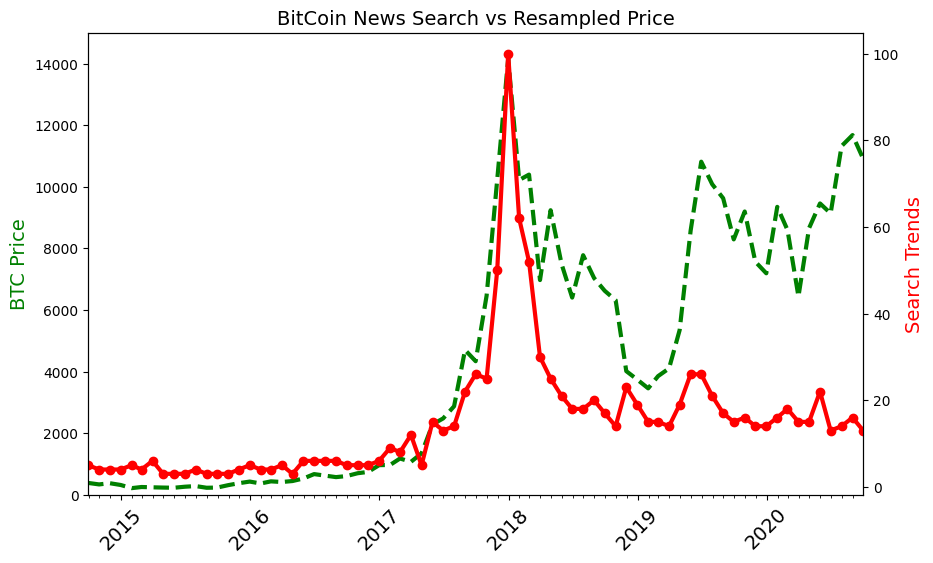

In [108]:
plt.figure(figsize=(10,6))
plt.title("BitCoin News Search vs Resampled Price", fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylabel("BTC Price", fontsize=14, color="green")
ax2.set_ylabel("Search Trends", color='red',fontsize=14)

ax1.xaxis.set_major_formatter(year_fmt)
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_minor_locator(months)

ax1.set_ylim(bottom=0, top=15000)
ax1.set_xlim([df_btc_monthly.index.min(), df_btc_monthly.index.max()])


ax1.plot(df_btc_monthly.index, df_btc_monthly.CLOSE,color='green', linewidth=3, linestyle='--')
ax2.plot(df_btc_monthly.index, df_btc_search.BTC_NEWS_SEARCH, color='red', linewidth=3, marker='o')


plt.show()


<h1>vData Visualisation - Unemployment: How to use Grids</h1>


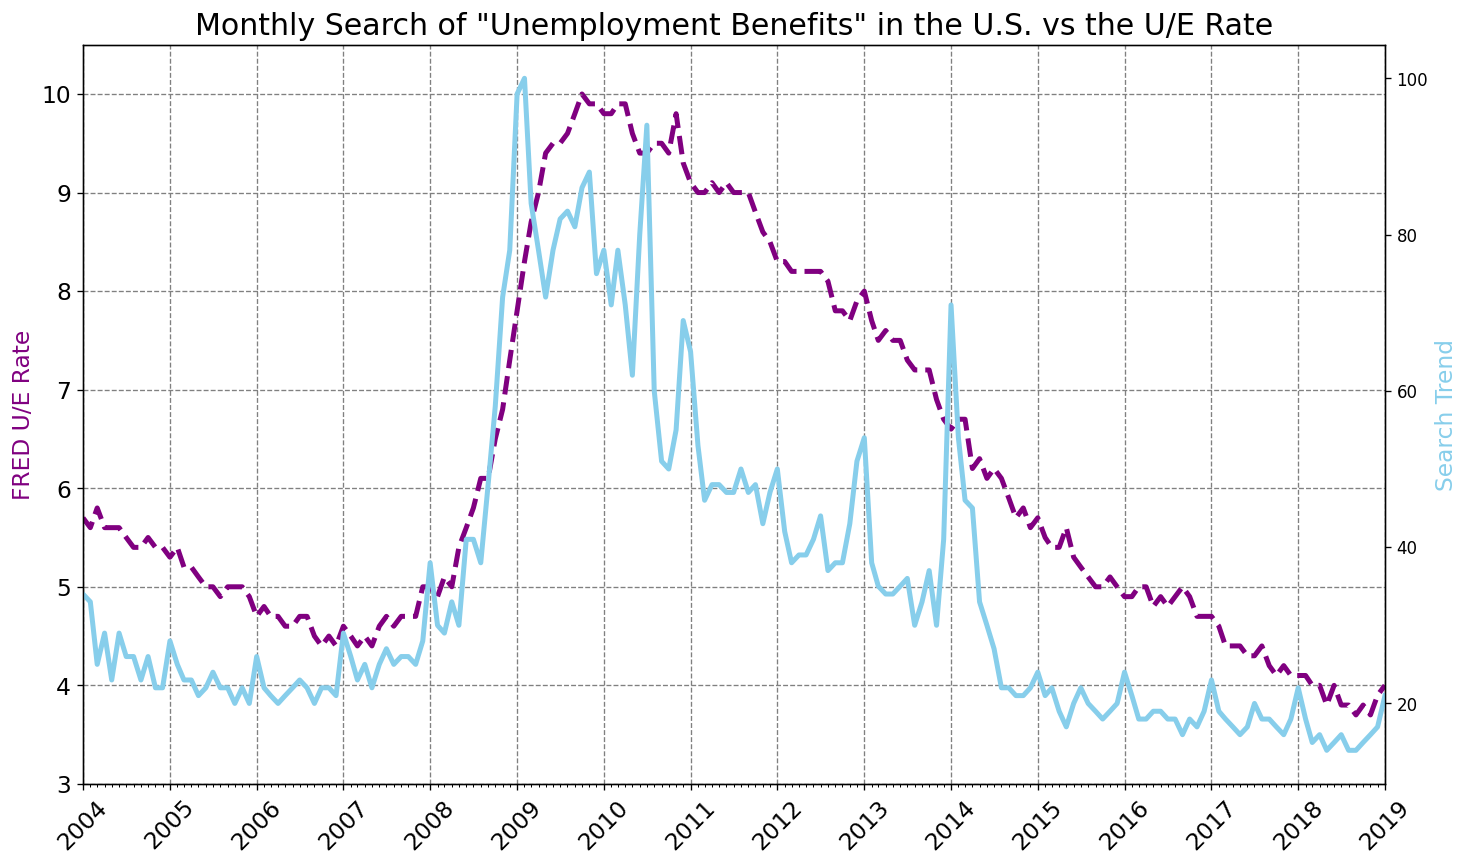

In [112]:
plt.figure(figsize=(14,8), dpi=120)
plt.title('Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate', fontsize=18)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(year_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.set_ylim(bottom=3, top=10.5)
ax1.set_xlim([df_unemployment.MONTH.min(), df_unemployment.MONTH.max()])

ax1.set_ylabel('FRED U/E Rate', color='purple', fontsize=14)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=14)

ax1.grid(color='gray', linestyle="--")


ax1.plot(df_unemployment.MONTH, df_unemployment.UNRATE, color='purple', linewidth=3, linestyle='--')
ax2.plot(df_unemployment.MONTH, df_unemployment.UE_BENEFITS_WEB_SEARCH, color='skyblue', linewidth=3)

plt.show()
